# **Check Class Imbalance**

### **Objective**
Confirm the class balance of the target (`Status`) on `y_train` and decide
whether — and how — to handle the imbalance before training models.

**1-Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight


**2-Load y_train**

In [2]:
df = pd.read_csv("loan_data_processed_full.csv")
y_train = df[df["split"] == "train"]["Status"]

print(y_train.shape)
y_train.head()

(35000,)


,Status
0,0
1,0
2,0
3,0
4,1


**3-Quantify the Imbalance**

In [3]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100
print("Counts:\n", counts)
print("\nPercentages:\n", percentages)
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")


Counts:
 Status
0    26375
1     8625
Name: count, dtype: int64

Percentages:
 Status
0    75.357143
1    24.642857
Name: proportion, dtype: float64

Imbalance ratio (majority : minority) = 3.06 : 1


**4-Visualize the Class Balance**

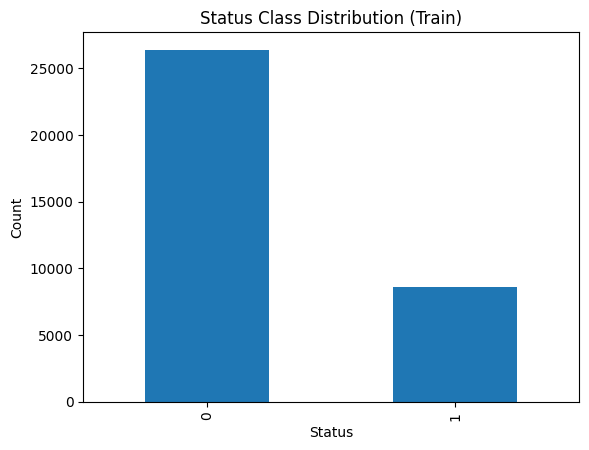

In [4]:
counts.plot(kind="bar")
plt.title("Status Class Distribution (Train)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


**5-Compute Class Weights**

In [5]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
classes = np.unique(y_train)
class_weight_dict = {}
for i in range(len(classes)):
    class_weight_dict[classes[i]] = class_weights[i]

print(class_weight_dict)


{np.int64(0): np.float64(0.6635071090047393), np.int64(1): np.float64(2.028985507246377)}


**6-Save the Class Weights for the Modeling Step**

In [6]:
import json

weights = {str(key): value for key, value in class_weight_dict.items()}
with open("class_weights.json", "w") as file:
    json.dump(weights, file, indent=4)


# **Build Baseline Models**

**1-Import Libraries**

In [7]:
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, RocCurveDisplay, f1_score, make_scorer)


**2-Load the Processed Dataset**

In [8]:
df = pd.read_csv("loan_data_processed_full.csv")
df.head()


,num__loan_amount,num__term,num__income,num__Credit_Score,ord__age,nom__loan_limit_cf,nom__loan_limit_ncf,nom__Gender_Female,nom__Gender_Joint,nom__Gender_Male,...,nom__submission_of_application_not_inst,nom__submission_of_application_to_inst,nom__Region_central,nom__Region_north,nom__Region_north-east,nom__Region_south,nom__Security_Type_Indirect,nom__Security_Type_direct,Status,split
0,-0.189927,0.427849,-0.520808,-0.581389,6.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,train
1,1.476312,0.427849,0.138636,0.586944,4.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,train
2,-0.781173,0.427849,-0.660128,0.861846,5.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0,train
3,0.777567,0.427849,-0.056411,0.458084,3.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,train
4,0.025072,0.427849,-0.474369,-0.375213,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1,train


**3-Recover Train / Val / Test from the `split` Column**

`df` already carries a `split` column (`"train"` / `"val"` / `"test"`) set
when the data was originally split and preprocessed. Filtering by it here
— instead of running a fresh `train_test_split` on the combined file —
keeps that same partition intact. Re-splitting randomly at this point
would risk mixing rows that were used to fit the preprocessing
(imputation/encoding/scaling) into the test set, which is a leakage risk.

In [9]:
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

X_train = train_df.drop(columns=["Status", "split"])
y_train = train_df["Status"]

X_val = val_df.drop(columns=["Status", "split"])
y_val = val_df["Status"]

X_test = test_df.drop(columns=["Status", "split"])
y_test = test_df["Status"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (35000, 56)
X_val: (7500, 56)
X_test: (7500, 56)


**4-Sanity Check — No Leftover Text Columns**

In [10]:
print(X_train.select_dtypes(include="object").columns)


Index([], dtype='object')


**5-Define Candidate Models**

In [11]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}


**6-Train Baseline Models on Train, Evaluate on Validation**

In [12]:
baseline_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    train_acc = (y_train_pred == y_train).mean()
    val_acc = (y_pred == y_val).mean()

    baseline_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "f1": f1_score(y_val, y_pred, pos_label=1),
        "recall": (y_pred[y_val == 1] == 1).mean(),
        "roc_auc": roc_auc_score(y_val, y_proba)
    }
    print(f"\n=== {name} ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(classification_report(y_val, y_pred))
    print(f"ROC-AUC: {baseline_results[name]['roc_auc']:.4f}")



=== Logistic Regression ===
Train Accuracy: 0.8257
Validation Accuracy: 0.8285
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      5651
           1       0.66      0.64      0.65      1849

    accuracy                           0.83      7500
   macro avg       0.77      0.76      0.77      7500
weighted avg       0.83      0.83      0.83      7500

ROC-AUC: 0.8344

=== Decision Tree ===
Train Accuracy: 1.0000
Validation Accuracy: 0.7971
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      5651
           1       0.59      0.59      0.59      1849

    accuracy                           0.80      7500
   macro avg       0.73      0.73      0.73      7500
weighted avg       0.80      0.80      0.80      7500

ROC-AUC: 0.7287

=== Random Forest ===
Train Accuracy: 1.0000
Validation Accuracy: 0.8691
              precision    recall  f1-score   support

           0       0.86      0.

**7-Compare Baselines**

In [13]:
baseline_table = pd.DataFrame({
    "Model": baseline_results.keys(),
    "Train Accuracy": [r["train_acc"] for r in baseline_results.values()],
    "Validation Accuracy": [r["val_acc"] for r in baseline_results.values()],
    "F1": [r["f1"] for r in baseline_results.values()],
    "Recall": [r["recall"] for r in baseline_results.values()],
    "ROC-AUC": [r["roc_auc"] for r in baseline_results.values()]
})

baseline_table = baseline_table.sort_values("F1", ascending=False)
baseline_table


,Model,Train Accuracy,Validation Accuracy,F1,Recall,ROC-AUC
3,Gradient Boosting,0.875571,0.874667,0.674515,0.526771,0.864502
2,Random Forest,1.000000,0.869067,0.662311,0.520822,0.848936
0,Logistic Regression,0.825714,0.828533,0.647478,0.638724,0.834439
5,Naive Bayes,0.858371,0.860400,0.624866,0.471606,0.817811
1,Decision Tree,1.000000,0.797067,0.590640,0.593835,0.728699
4,KNN,0.872114,0.840267,0.581412,0.449973,0.778268


**8-Cross-Validation (Train Only)**

`StratifiedKFold` is used instead of a plain integer `cv=5` so the class
balance is preserved in every fold, which matters with an imbalanced
target like this one.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score, pos_label=1)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=f1_scorer)
    cv_results[name] = scores.mean()
    print(f"{name}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression: F1 = 0.6359 (+/- 0.0056)
Decision Tree: F1 = 0.5877 (+/- 0.0051)
Random Forest: F1 = 0.6497 (+/- 0.0046)
Gradient Boosting: F1 = 0.6652 (+/- 0.0029)
KNN: F1 = 0.5780 (+/- 0.0112)
Naive Bayes: F1 = 0.6170 (+/- 0.0065)


**9-Tune the Best Candidate**

In [15]:
best_candidate_name = "Gradient Boosting"

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    models[best_candidate_name],
    param_dist,
    n_iter=20,
    cv=cv,
    scoring=f1_scorer,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)


Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.2}
Best CV F1: 0.6722150793956666


**10-Evaluate the Tuned Model on Validation**

In [16]:
tuned_model = random_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_val)
y_proba_tuned = tuned_model.predict_proba(X_val)[:, 1]

print(f"=== Tuned {best_candidate_name} ===")
print(classification_report(y_val, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_tuned))


=== Tuned Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      5651
           1       0.90      0.56      0.69      1849

    accuracy                           0.88      7500
   macro avg       0.89      0.77      0.81      7500
weighted avg       0.88      0.88      0.87      7500

ROC-AUC: 0.8584073481301356


**11-Confusion Matrix — Validation**

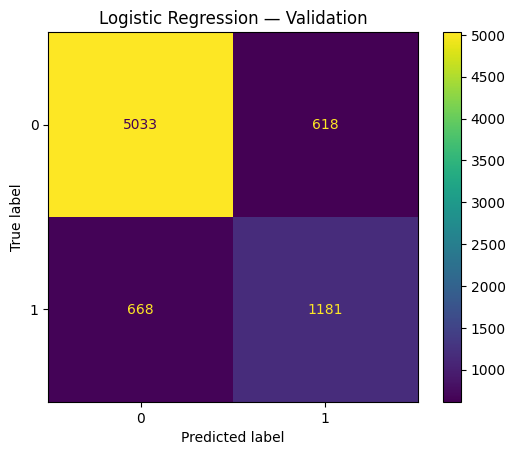

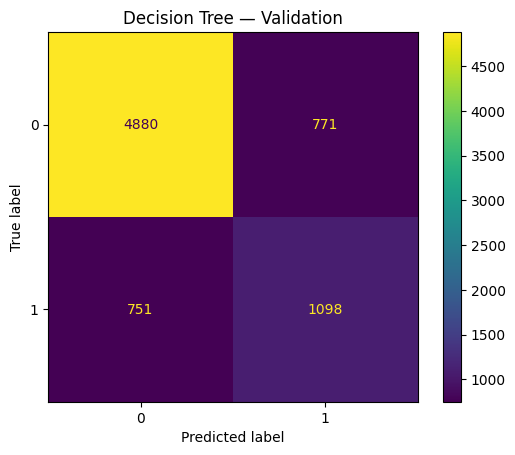

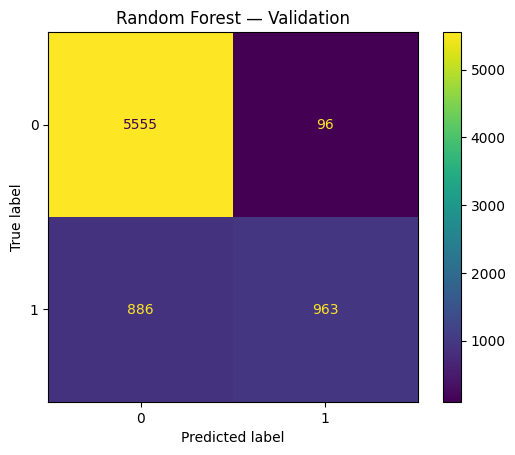

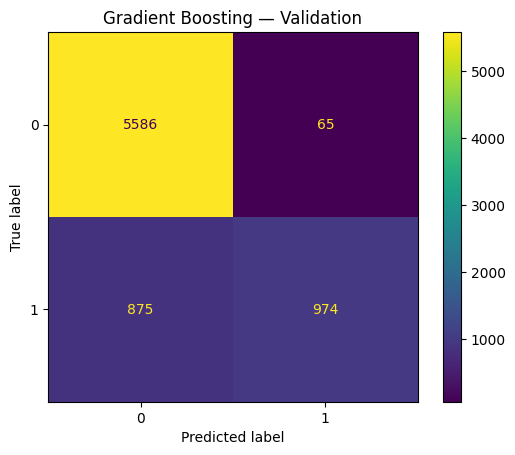

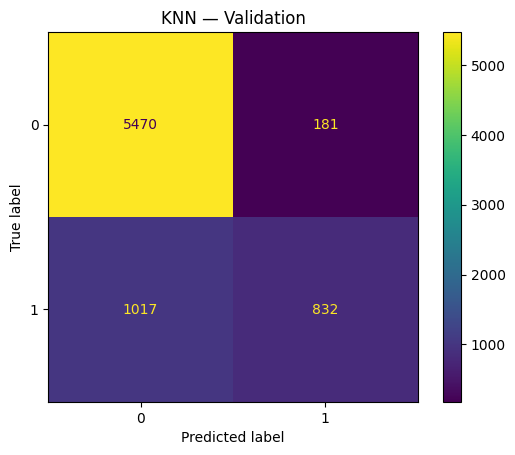

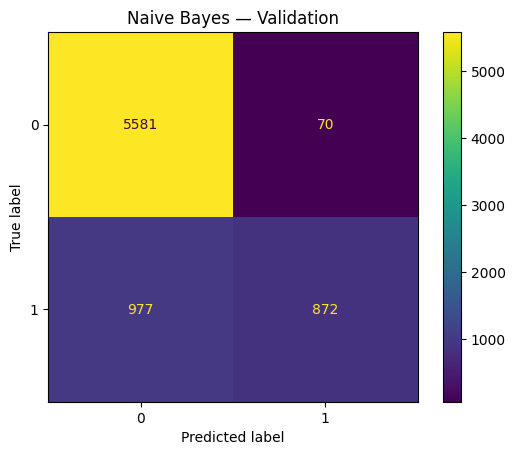

In [17]:
for name, result in baseline_results.items():
    ConfusionMatrixDisplay.from_predictions(y_val, result["y_pred"])
    plt.title(f"{name} — Validation")
    plt.show()


**12-Select the Final Model**

In [18]:
final_model = tuned_model
winner_name = f"{best_candidate_name} (Tuned)"
print("Final model:", winner_name)


Final model: Gradient Boosting (Tuned)


**13-Final Evaluation on Test Set**

The one and only time `X_test` / `y_test` are used.

In [19]:
y_pred_test = final_model.predict(X_test)
y_proba_test = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))


              precision    recall  f1-score   support

           0       0.87      0.98      0.92      5652
           1       0.88      0.54      0.67      1848

    accuracy                           0.87      7500
   macro avg       0.88      0.76      0.80      7500
weighted avg       0.87      0.87      0.86      7500

ROC-AUC: 0.8516800933202208


**14-Confusion Matrix & ROC Curve — Test**

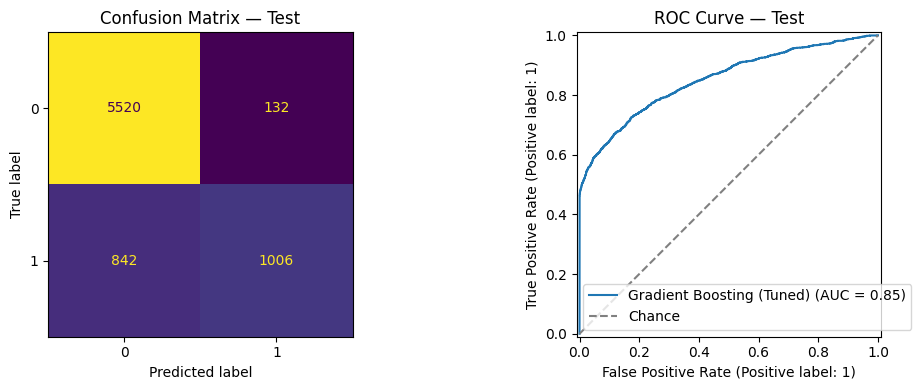

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Test")

RocCurveDisplay.from_predictions(y_test, y_proba_test, name=winner_name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axes[1].set_title("ROC Curve — Test")
axes[1].legend()

plt.tight_layout()
plt.show()


**15-Feature Importance**

In [21]:
importance = final_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df.head(10)


,Feature,Importance
44,nom__credit_type_EQUI,0.653908
2,num__income,0.088096
0,num__loan_amount,0.042269
3,num__Credit_Score,0.024726
26,nom__Neg_ammortization_not_neg,0.022156
30,nom__lump_sum_payment_not_lpsm,0.018021
29,nom__lump_sum_payment_lpsm,0.014957
20,nom__Credit_Worthiness_l2,0.011690
48,nom__submission_of_application_not_inst,0.010865
25,nom__Neg_ammortization_neg_amm,0.010364


**16-Save the Final Model**

In [22]:
import joblib

joblib.dump(final_model, "model.pkl")
print("Saved model.pkl")


Saved model.pkl
